<a href="https://colab.research.google.com/github/carpinetti/2025A-CPGINV-HPC-0012/blob/main/Travelling_Salesman_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Universidade SENAI CIMATEC**

Turma: 98901

Disciplina: CPGINV-HPC-0013 Algoritmos Quânticos

Prof.º Dr. Luiz Gustavo Esmenard Arruda

Atividade Hands-On UA 3 e UA 4

Autores: (Grupo 1)
* Anderson Garcia
* Ézio Rego
* Joseane de Almeida
* Fabio Pires

In [260]:
import time
import itertools
import math
import time
from collections.abc import Sequence

In [261]:

Numero: TypeAlias = int | float
Matriz: TypeAlias = Sequence[Sequence[Numero]]

def calcular_custo_rota(
    rota: Sequence[int],
    matriz: Matriz,
) -> Numero:
    """Calcula o custo total de uma rota."""
    return sum(
        matriz[rota[i]][rota[i + 1]]
        for i in range(len(rota) - 1)
    )

def _validar_matriz(matriz: Matriz) -> None:
    """Valida as dimensões básicas da matriz de custos."""
    n = len(matriz)

    if n < 2:
        raise ValueError(
            "O TSP requer pelo menos duas cidades."
        )

    if any(len(linha) != n for linha in matriz):
        raise ValueError(
            "A matriz de custos deve ser quadrada."
        )



##**Resolve o problema do Caixeiro Viajante (TSP - Travelling Salesman Problem) utilizando o algoritmo de força bruta.**

### Parâmetros
----------
**matriz** : list[list[float]]
    Matriz de custos/distâncias entre as cidades.

### Retorna
-------
**melhor_rota** : list[int]
    Sequência das cidades da rota ótima, incluindo o retorno à cidade inicial.

**menor_custo** : float
    Custo total da rota ótima.

**rotas_avaliadas** : int
    Número de rotas avaliadas.

**tempo_execucao** : float
    Tempo total de execução em segundos.

In [262]:
def tsp_forca_bruta(
    matriz: Matriz,
) -> tuple[list[int], Numero, int, float]:
    """Resolve o TSP avaliando todas as permutações possíveis.

    A cidade de índice 0 permanece fixa como origem e destino.
    Consequentemente, são avaliadas exatamente (n - 1)! rotas.

    Args:
        matriz:
            Matriz quadrada de custos entre as cidades.

    Returns:
        Tupla contendo:
        - melhor rota encontrada;
        - custo ótimo;
        - quantidade de rotas completas avaliadas;
        - tempo de execução.

    Raises:
        ValueError:
            Se a matriz não for quadrada ou tiver menos de duas cidades.
        RuntimeError:
            Se nenhuma rota válida for encontrada ou se a quantidade de
            permutações processadas divergir de (n - 1)!.
    """
    _validar_matriz(matriz)

    n = len(matriz)
    cidade_inicial = 0

    melhor_custo = math.inf
    melhor_rota: list[int] = []
    rotas_avaliadas = 0

    inicio = time.perf_counter()

    for rota_parcial in itertools.permutations(range(1, n)):
        rota = [
            cidade_inicial,
            *rota_parcial,
            cidade_inicial,
        ]

        rotas_avaliadas += 1

        custo_atual = calcular_custo_rota(
            rota,
            matriz,
        )

        if custo_atual < melhor_custo:
            melhor_custo = custo_atual
            melhor_rota = rota

    tempo_execucao = time.perf_counter() - inicio

    rotas_teoricas = math.factorial(n - 1)

    if rotas_avaliadas != rotas_teoricas:
        raise RuntimeError(
            "Quantidade inesperada de rotas avaliadas: "
            f"obtido={rotas_avaliadas}, "
            f"esperado={rotas_teoricas}."
        )

    if not melhor_rota:
        raise RuntimeError(
            "Nenhuma rota Hamiltoniana válida foi encontrada."
        )

    return (
        melhor_rota,
        melhor_custo,
        rotas_avaliadas,
        tempo_execucao,
    )

##**Resolve o problema do Caixeiro Viajante (TSP - Travelling Salesman Problem) utilizando o algoritmo Held-Karp.**

### Parâmetros
----------
**matriz** : list[list[float]]
    Matriz de custos/distâncias entre as cidades.

### Retorna
-------
**melhor_rota** : list[int]
    Sequência das cidades da rota ótima,
    incluindo o retorno à cidade inicial.

**menor_custo** : float
    Custo total da rota ótima.

**estados_avaliados** : int
    Número de estados de programação dinâmica calculados.

**tempo_execucao** : float
    Tempo total de execução em segundos.


In [263]:
# held_karp.py

import math
import time
from collections.abc import Sequence


def tsp_held_karp(
    matriz: Sequence[Sequence[float]],
) -> tuple[list[int], float, int, float]:
    """Resolve o TSP pelo algoritmo Held-Karp.

    Args:
        matriz:
            Matriz quadrada de custos entre as cidades.

    Returns:
        Tupla contendo:
        - rota ótima;
        - custo ótimo;
        - número de estados distintos da programação dinâmica;
        - tempo de execução.

    Raises:
        ValueError:
            Se a matriz não for quadrada ou possuir menos de duas cidades.
        RuntimeError:
            Se não for possível construir um ciclo Hamiltoniano ou se a
            reconstrução da rota não corresponder ao custo calculado pela DP.
    """
    n = len(matriz)

    if n < 2:
        raise ValueError(
            "Held-Karp requer pelo menos duas cidades."
        )

    if any(len(linha) != n for linha in matriz):
        raise ValueError(
            "A matriz de custos deve ser quadrada."
        )

    cidade_inicial = 0
    inicio = time.perf_counter()

    dp: dict[tuple[int, int], tuple[float, int | None]] = {}

    mascara_inicial = 1 << cidade_inicial

    dp[(mascara_inicial, cidade_inicial)] = (
        0.0,
        None,
    )

    estados_avaliados = 1

    for mascara in range(1 << n):
        if not mascara & mascara_inicial:
            continue

        for cidade_atual in range(1, n):
            bit_cidade_atual = 1 << cidade_atual

            if not mascara & bit_cidade_atual:
                continue

            mascara_anterior = mascara ^ bit_cidade_atual

            melhor_custo_estado = math.inf
            melhor_cidade_anterior = None

            for cidade_anterior in range(n):
                bit_cidade_anterior = 1 << cidade_anterior

                if not mascara_anterior & bit_cidade_anterior:
                    continue

                estado_anterior = (
                    mascara_anterior,
                    cidade_anterior,
                )

                if estado_anterior not in dp:
                    continue

                custo_anterior = dp[estado_anterior][0]

                custo_candidato = (
                    custo_anterior
                    + matriz[cidade_anterior][cidade_atual]
                )

                if custo_candidato < melhor_custo_estado:
                    melhor_custo_estado = custo_candidato
                    melhor_cidade_anterior = cidade_anterior

            if melhor_cidade_anterior is None:
                continue

            dp[(mascara, cidade_atual)] = (
                melhor_custo_estado,
                melhor_cidade_anterior,
            )

            estados_avaliados += 1

    mascara_completa = (1 << n) - 1

    custo_otimo = math.inf
    ultima_cidade = None

    for cidade_atual in range(1, n):
        estado = (
            mascara_completa,
            cidade_atual,
        )

        if estado not in dp:
            continue

        custo_candidato = (
            dp[estado][0]
            + matriz[cidade_atual][cidade_inicial]
        )

        if custo_candidato < custo_otimo:
            custo_otimo = custo_candidato
            ultima_cidade = cidade_atual

    if ultima_cidade is None or math.isinf(custo_otimo):
        raise RuntimeError(
            "Não foi possível encontrar um ciclo Hamiltoniano válido."
        )

    rota_reversa: list[int] = []

    mascara = mascara_completa
    cidade_atual: int | None = ultima_cidade

    while cidade_atual is not None:
        rota_reversa.append(cidade_atual)

        _, cidade_anterior = dp[
            (mascara, cidade_atual)
        ]

        mascara ^= 1 << cidade_atual
        cidade_atual = cidade_anterior

    melhor_rota = list(reversed(rota_reversa))
    melhor_rota.append(cidade_inicial)

    custo_rota = calcular_custo_rota(
        melhor_rota,
        matriz,
    )

    if not math.isclose(
        custo_otimo,
        custo_rota,
        rel_tol=1e-9,
        abs_tol=1e-9,
    ):
        raise RuntimeError(
            "A reconstrução da rota é inconsistente com a DP: "
            f"custo DP={custo_otimo}, "
            f"custo da rota={custo_rota}."
        )

    tempo_execucao = time.perf_counter() - inicio

    return (
        melhor_rota,
        custo_otimo,
        estados_avaliados,
        tempo_execucao,
    )

## Testes de Comparação

Vamos comparar o desempenho e a correção dos algoritmos de Força Bruta e Held-Karp utilizando algumas matrizes de distância de exemplo.

### Observações

Observe que, para um número pequeno de cidades (como 4, 5 ou mesmo 6), o tempo de execução pode ser similar. No entanto, à medida que o número de cidades aumenta, a complexidade exponencial da força bruta a torna impraticável, enquanto Held-Karp, embora ainda exponencial, é significativamente mais eficiente.

Para 10 cidades, o algoritmo de Força Bruta precisará calcular 9! (362.880) permutações, o que levará um tempo considerável. Já o Held-Karp será comparativamente mais rápido, mas ainda assim exponenciará em `N`.

Para 16 cidades,  **o algoritmo de Força Bruta precisaria calcular 15! (cerca de 1,3 trilhões)**. Considerando o desempenho observado para a instância de 10 cidades, de aproximadamente 435 mil rotas por segundo, uma extrapolação simples resultaria em cerca de 35 dias de execução contínua. Considerando também o aumento do custo computacional para avaliar cada rota maior, o tempo poderia atingir aproximadamente 56 dias. Por essa razão, a execução por força bruta para 16 cidades foi considerada impraticável no contexto do experimento.

In [264]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns

from collections.abc import Collection, Mapping, Sequence
from typing import Any, TypeAlias
from pandas.io.formats.style import Styler

def gerar_matriz_distancia_aleatoria(
    n_cidades: int,
    seed: int | None = None,
) -> list[list[int]]:
    """Gera uma matriz simétrica aleatória reproduzível."""
    rng = random.Random(seed)

    matriz = [
        [0] * n_cidades
        for _ in range(n_cidades)
    ]

    for i in range(n_cidades):
        for j in range(i + 1, n_cidades):
            distancia = rng.randint(1, 100)

            matriz[i][j] = distancia
            matriz[j][i] = distancia

    return matriz


def gerar_instancias_independentes(
    qtd_cidades: list[int],
    seed_base: int,
) -> dict[int, list[list[int]]]:
    """Gera uma instância aleatória independente para cada tamanho."""
    return {
        n: gerar_matriz_distancia_aleatoria(
            n,
            seed=seed_base + n,
        )
        for n in qtd_cidades
    }


def gerar_instancias_aninhadas_euclidianas(
    qtd_cidades: list[int],
    seed: int,
    limite: float = 100.0,
) -> dict[int, list[list[float]]]:
    """Gera instâncias aninhadas usando distâncias euclidianas."""
    if not qtd_cidades:
        raise ValueError("QTD_CIDADES não pode estar vazio.")

    maior_n = max(qtd_cidades)
    rng = random.Random(seed)

    coordenadas = [
        (
            rng.uniform(0, limite),
            rng.uniform(0, limite),
        )
        for _ in range(maior_n)
    ]

    matriz_completa = [
        [0.0] * maior_n
        for _ in range(maior_n)
    ]

    for i in range(maior_n):
        for j in range(i + 1, maior_n):
            x1, y1 = coordenadas[i]
            x2, y2 = coordenadas[j]

            distancia = math.hypot(
                x2 - x1,
                y2 - y1,
            )

            matriz_completa[i][j] = distancia
            matriz_completa[j][i] = distancia

    return {
        n: [
            linha[:n]
            for linha in matriz_completa[:n]
        ]
        for n in qtd_cidades
    }

def _validar_instancia(n: int, matriz: Matriz) -> None:
    """Valida se a matriz representa uma instância TSP n x n."""
    if n < 2:
        raise ValueError(
            f"A quantidade de cidades deve ser pelo menos 2. Recebido: {n}."
        )

    if len(matriz) != n:
        raise ValueError(
            f"Instância declarada com {n} cidades, "
            f"mas a matriz possui {len(matriz)} linhas."
        )

    for indice, linha in enumerate(matriz):
        if len(linha) != n:
            raise ValueError(
                f"Linha {indice} possui {len(linha)} elementos; "
                f"esperados: {n}."
            )


def calcular_estados_held_karp_teoricos(n: int) -> int:
    """Calcula o número de estados DP do Held-Karp usado no experimento.

    Considera:
        - cidade 0 fixa como origem;
        - um estado inicial;
        - estados (subconjunto, última cidade) para as demais cidades.
    """
    if n < 2:
        raise ValueError(
            "O cálculo requer pelo menos duas cidades."
        )

    return 1 + (n - 1) * (2 ** (n - 2))


def calcular_rotas_forca_bruta_teoricas(n: int) -> int:
    """Calcula o número de rotas com a cidade 0 fixa na origem."""
    if n < 2:
        raise ValueError(
            "O cálculo requer pelo menos duas cidades."
        )

    return math.factorial(n - 1)


def formatar_resultados(
    resultados: list[dict],
) -> Styler:
    """Formata os resultados dos experimentos para apresentação."""
    df = pd.DataFrame(resultados)

    colunas_inteiras = [
        "cidades",
        "estados_held_karp",
        "estados_held_karp_teoricos",
        "rotas_forca_bruta",
        "rotas_forca_bruta_teoricas",
    ]

    for coluna in colunas_inteiras:
        if coluna in df.columns:
            df[coluna] = df[coluna].astype("Int64")

    formatacao = {
        "cidades": "{:d}",
        "custo_otimo": "{:.2f}",
        "tempo_held_karp": "{:.6f}",
        "estados_held_karp": "{:,d}",
        "estados_held_karp_teoricos": "{:,d}",
        "tempo_forca_bruta": "{:.6f}",
        "rotas_forca_bruta": "{:,d}",
        "rotas_forca_bruta_teoricas": "{:,d}",
        "razao_espaco_busca_teorico_fb_hk": "{:.2f}",
    }

    formatacao = {
        coluna: formato
        for coluna, formato in formatacao.items()
        if coluna in df.columns
    }

    return df.style.format(
        formatacao,
        na_rep="—",
        decimal=",",
        thousands=".",
    )


In [265]:
# Seed fixa para garantir reprodutibilidade
QTD_CIDADES = [3, 4, 5, 6, 10, 12, 16]
SEED_BASE = 42

instancias = gerar_instancias_aninhadas_euclidianas(
    qtd_cidades=QTD_CIDADES,
    seed=SEED_BASE,
)

QTD_CIDADES_FORCA_BRUTA = [3, 4, 5, 6, 10, 12]


In [266]:
def executar_experimentos_classicos(
    instancias: Mapping[int, Matriz],
    qtd_cidades_forca_bruta: Collection[int],
) -> list[dict[str, Any]]:
    """Executa e compara Held-Karp e força bruta para instâncias TSP.

    Held-Karp é executado para todas as instâncias. A força bruta é
    executada somente para tamanhos presentes em
    ``qtd_cidades_forca_bruta``.

    Além das métricas observadas, registra as contagens teóricas do
    espaço de busca de cada algoritmo.

    Args:
        instancias:
            Mapeamento entre quantidade de cidades e matriz de custos.
        qtd_cidades_forca_bruta:
            Tamanhos para os quais a força bruta deve ser executada.

    Returns:
        Lista de dicionários com resultados e métricas experimentais.

    Raises:
        ValueError:
            Se uma instância for inválida.
        RuntimeError:
            Se algoritmos exatos produzirem custos diferentes ou se a
            força bruta avaliar quantidade inesperada de rotas.
    """
    resultados: list[dict[str, Any]] = []

    for n, matriz in instancias.items():
        _validar_instancia(n, matriz)

        print(f"Executando TSP com {n} cidades...")

        estados_hk_teoricos = calcular_estados_held_karp_teoricos(n)
        rotas_fb_teoricas = calcular_rotas_forca_bruta_teoricas(n)

        (
            rota_hk,
            custo_hk,
            estados_hk,
            tempo_hk,
        ) = tsp_held_karp(matriz)

        validacao_estados_hk = (
            estados_hk == estados_hk_teoricos
        )

        rota_fb = None
        custo_fb = None
        rotas_fb = None
        tempo_fb = None
        validacao_custo = None
        validacao_rotas_fb = None

        executar_forca_bruta = (
            n in qtd_cidades_forca_bruta
        )

        if executar_forca_bruta:
            (
                rota_fb,
                custo_fb,
                rotas_fb,
                tempo_fb,
            ) = tsp_forca_bruta(matriz)

            validacao_custo = math.isclose(
                custo_hk,
                custo_fb,
                rel_tol=1e-9,
                abs_tol=1e-9,
            )

            if not validacao_custo:
                raise RuntimeError(
                    f"Divergência para {n} cidades: "
                    f"Held-Karp={custo_hk}, "
                    f"Força Bruta={custo_fb}."
                )

            validacao_rotas_fb = (
                rotas_fb == rotas_fb_teoricas
            )

            if not validacao_rotas_fb:
                raise RuntimeError(
                    f"Contagem inesperada na força bruta para {n} cidades: "
                    f"avaliadas={rotas_fb}, "
                    f"esperadas={rotas_fb_teoricas}."
                )

        razao_espaco_busca_teorico = (
            rotas_fb_teoricas
            / estados_hk_teoricos
        )

        resultados.append(
            {
                "cidades": n,

                "rota_held_karp": rota_hk,
                "tempo_held_karp": tempo_hk,
                "estados_held_karp": estados_hk,
                "estados_held_karp_teoricos": estados_hk_teoricos,
                "custo_held_karp": custo_hk,

                "rota_forca_bruta": rota_fb,
                "tempo_forca_bruta": tempo_fb,
                "rotas_forca_bruta": rotas_fb,
                "rotas_forca_bruta_teoricas": rotas_fb_teoricas,
                "custo_forca_bruta": custo_fb,

                "status_forca_bruta": (
                    "Executado"
                    if executar_forca_bruta
                    else "Não executado"
                ),

                "razao_espaco_busca_teorico_fb_hk":
                    razao_espaco_busca_teorico,
            }
        )

    return resultados

#### Executa experimentos clássicos, sendo força bruta apenas nas quantidades configurados e Held-Karp em todas as instâncias.

In [267]:

resultados_classicos = executar_experimentos_classicos(
    instancias,
    QTD_CIDADES_FORCA_BRUTA
)


Executando TSP com 3 cidades...
Executando TSP com 4 cidades...
Executando TSP com 5 cidades...
Executando TSP com 6 cidades...
Executando TSP com 10 cidades...
Executando TSP com 12 cidades...
Executando TSP com 16 cidades...


### Métricas e gráficos do processamento

In [268]:
df_resultados = pd.DataFrame(resultados_classicos)

colunas_inteiras = [
    "cidades",
    "estados_held_karp",
    "estados_held_karp_teoricos",
    "rotas_forca_bruta",
    "rotas_forca_bruta_teoricas",
]

for coluna in colunas_inteiras:
    if coluna in df_resultados.columns:
        df_resultados[coluna] = df_resultados[coluna].astype("Int64")



#### Tabela analitica

In [269]:

tabela_formatada = formatar_resultados(resultados_classicos)


#### Gráfico comparativo do tempo de execução entre as soluções

In [270]:
def plotar_tempo_execucao(
    resultados: list[dict],
) -> None:
    # Filter out cases where force brute was not executed for plotting
    df_plot = df_resultados[df_resultados['status_forca_bruta'] == 'Executado'].copy()

    plt.figure(figsize=(12, 7))
    sns.lineplot(
    x='cidades',
    y='tempo_held_karp',
    data=df_resultados,
    marker='o',
    label='Held-Karp',
    )
    sns.lineplot(
    x='cidades',
    y='tempo_forca_bruta',
    data=df_plot,
    marker='s',
    label='Força Bruta',
    )

    plt.title('Comparativo de Tempo de Execução: Held-Karp vs Força Bruta')
    plt.xlabel('Número de Cidades')
    plt.ylabel('Tempo de Execução (segundos, escala logarítmica)')
    plt.yscale('log') # Use log scale due to large differences in execution time
    plt.xticks(df_resultados['cidades'].unique())
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show()

#### Gráfico em barras comparativo do custos das rotas.

In [271]:
def plotar_custos(
    resultados: list[dict],
) -> None:
    """Compara os custos encontrados por Força Bruta e Held-Karp."""
    df = pd.DataFrame(resultados)

    colunas_obrigatorias = {
        "cidades",
        "custo_held_karp",
        "custo_forca_bruta",
    }

    colunas_ausentes = colunas_obrigatorias - set(df.columns)

    if colunas_ausentes:
        raise ValueError(
            "Colunas ausentes nos resultados: "
            + ", ".join(sorted(colunas_ausentes))
        )

    df = df.dropna(
        subset=[
            "custo_held_karp",
            "custo_forca_bruta",
        ]
    ).sort_values("cidades")

    if df.empty:
        raise ValueError(
            "Não há resultados com Força Bruta e Held-Karp "
            "executados simultaneamente."
        )

    posicoes = np.arange(len(df))
    largura = 0.36

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        posicoes - largura / 2,
        df["custo_held_karp"],
        largura,
        label="Held-Karp",
    )

    ax.bar(
        posicoes + largura / 2,
        df["custo_forca_bruta"],
        largura,
        label="Força Bruta",
    )

    ax.set_title("Custo das rotas")
    ax.set_xlabel("Número de cidades")
    ax.set_ylabel("Custo")

    ax.set_xticks(posicoes)
    ax.set_xticklabels(
        df["cidades"].astype(int)
    )

    ax.legend()

    fig.tight_layout()
    plt.show()



#### Resultados

In [272]:
tabela_formatada

,cidades,rota_held_karp,tempo_held_karp,estados_held_karp,estados_held_karp_teoricos,custo_held_karp,rota_forca_bruta,tempo_forca_bruta,rotas_forca_bruta,rotas_forca_bruta_teoricas,custo_forca_bruta,status_forca_bruta,razao_espaco_busca_teorico_fb_hk
0,3,"[0, 2, 1, 0]","0,000063",5,5,"172,066448","[0, 1, 2, 0]","0,000013",2,2,"172,066448",Executado,"0,40"
1,4,"[0, 3, 2, 1, 0]","0,000040",13,13,"193,198810","[0, 1, 2, 3, 0]","0,000018",6,6,"193,198810",Executado,"0,46"
2,5,"[0, 4, 1, 2, 3, 0]","0,000094",33,33,"197,760477","[0, 3, 2, 1, 4, 0]","0,000037",24,24,"197,760477",Executado,"0,73"
3,6,"[0, 4, 1, 5, 2, 3, 0]","0,000134",81,81,"216,379627","[0, 3, 2, 5, 1, 4, 0]","0,000143",120,120,"216,379627",Executado,"1,48"
4,10,"[0, 9, 3, 7, 2, 8, 5, 6, 1, 4, 0]","0,006685",2.305,2.305,"264,138876","[0, 4, 1, 6, 5, 8, 2, 7, 3, 9, 0]","0,594596",362.880,362.880,"264,138876",Executado,"157,43"
5,12,"[0, 9, 3, 10, 2, 7, 8, 5, 6, 1, 11, 4, 0]","0,036334",11.265,11.265,"272,248766","[0, 4, 11, 1, 6, 5, 8, 7, 2, 10, 3, 9, 0]","83,010310",39.916.800,39.916.800,"272,248766",Executado,"3543,44"
6,16,"[0, 9, 3, 12, 14, 10, 15, 2, 7, 8, 5, 6, 13, 1, 11, 4, 0]","1,196655",245.761,245.761,"289,646424",—,—,—,1.307.674.368.000,—,Não executado,"5320918,97"


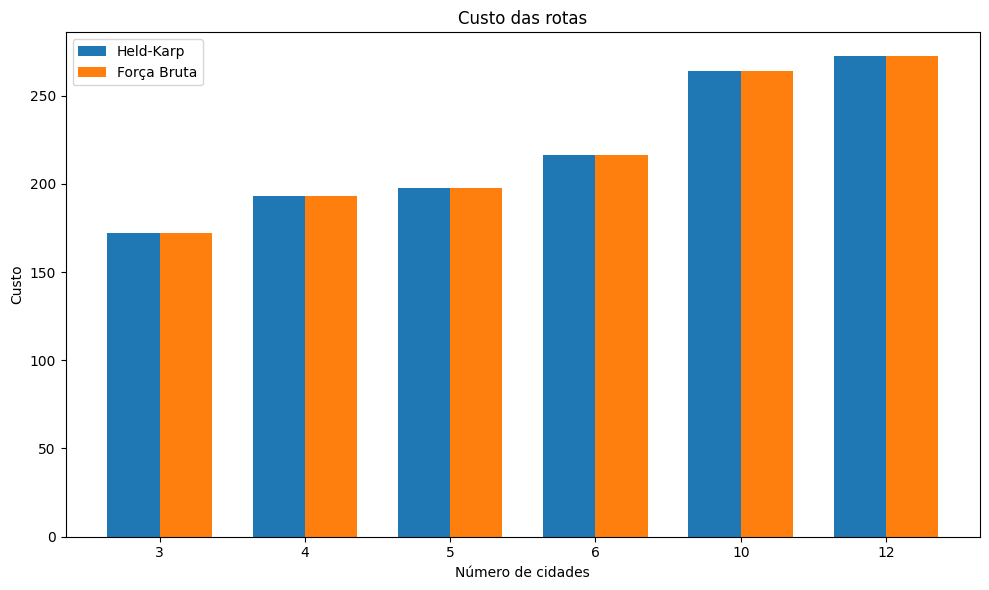

In [273]:

plotar_custos(resultados_classicos)


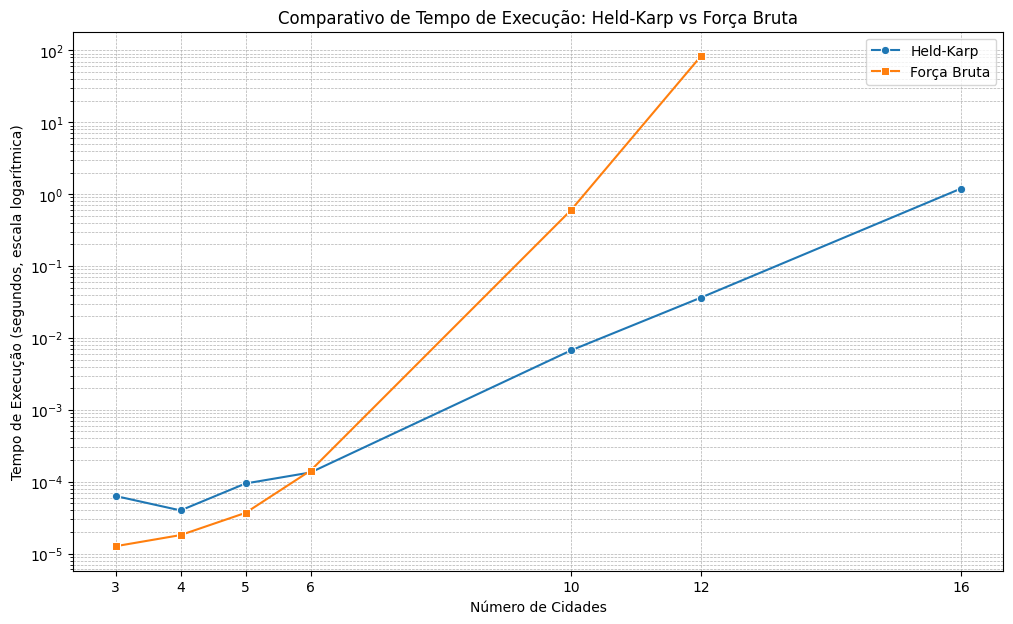

In [274]:
plotar_tempo_execucao(resultados_classicos)

##Implementação Qiskit
  [Warm-starting quantum optimization](https://qiskit-community.github.io/qiskit-optimization/tutorials/10_warm_start_qaoa.html)

  [Max-Cut and Traveling Salesman Problem](https://qiskit-community.github.io/qiskit-optimization/tutorials/06_examples_max_cut_and_tsp.html)


In [275]:
!pip install -q qiskit qiskit-aer qiskit-optimization